# Test of embeddings

Before using the speech embeddings for our actual trajectory and event analysis, we test whether they capture politically meaningful structure at all — specifically, whether (1) party membership can be recovered from the embeddings, (2) the embedding geometry aligns with established external ideology measures such as the Chapel Hill Expert Survey, and (3) documented political events (party switches, crises) appear as detectable movements in the embedding space.

In [1]:
!pip install umap-learn

In [32]:
# setup
import umap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn as sk
from scipy.stats import pearsonr
from collections import Counter

In [ ]:
# data frame with embedded speeches aggregated by MP and year
df_agg = pd.read_parquet("mp_year_embeddings_agg.parquet")
df_agg

,politicianId,year,party,n_speeches,embedding
0,-1,2000,PDS,27,"[0.056539893, -0.09861565, 0.03063002, 0.00181..."
1,-1,2001,PDS,25,"[0.021111745, -0.1159311, 0.028263073, 0.01033..."
2,-1,2002,CDU/CSU,20,"[0.056148797, -0.085535474, 0.052539904, 0.018..."
3,-1,2003,Grüne,38,"[0.057862733, -0.10331881, 0.066418335, 0.0417..."
4,-1,2004,FDP,47,"[0.05605023, -0.09303291, 0.056246977, 0.03644..."
...,...,...,...,...,...
12730,11004949,2020,SPD,4,"[-0.0029243752, -0.110075995, 0.062244855, -0...."
12731,11004949,2021,SPD,3,"[0.0056287777, -0.11775065, 0.088844776, -0.02..."
12732,11004951,2021,Grüne,1,"[0.00035163556, -0.05632198, 0.0993442, 0.0311..."
12733,11004956,2021,FDP,2,"[0.12558612, -0.13013785, 0.041155607, -0.0454..."


## 1. Party Affiliation Recovery

To test whether party affiliation is recoverable from the embeddings, we first project the aggregated MP-year embeddings to two dimensions using UMAP for a qualitative visual check, and then train a logistic regression classifier directly on the full-dimensional embeddings as a quantitative test of party-membership recovery.

### Visualization of embeddings using UMAP for dimensionality reduction

In [4]:
all_embeddings_agg = np.stack(df_agg["embedding"])
all_embeddings_agg.shape

(12735, 1024)

In [5]:
# dimensionality reduction of embeddings using UMAP
umap_model = umap.UMAP(n_components=2, random_state=42)
embeddings_2d = umap_model.fit_transform(all_embeddings_agg)

c:\Users\marle\anaconda3\envs\testenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


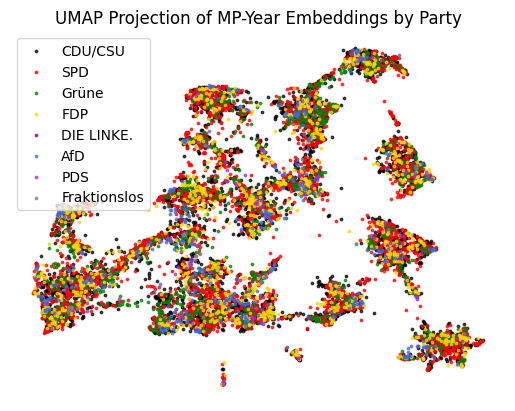

In [41]:
# plot reduced (2d) embeddings
df_for_umap_plot = pd.DataFrame({
    "dim1": embeddings_2d[:, 0],
    "dim2": embeddings_2d[:, 1],
    "party": df_agg.party
})

party_colors = {
    "CDU/CSU": "black", "SPD": "red", "Grüne": "green",
    "FDP": "gold", "DIE LINKE.": "purple", "AfD": "royalblue",
    "PDS": "darkorchid", "Fraktionslos": "grey",
}

for partei, color in party_colors.items():
    subset = df_for_umap_plot[df_for_umap_plot["party"] == partei]
    plt.scatter(subset["dim1"], subset["dim2"], color=color, label=partei, s=3, alpha = 0.7)

plt.legend()
plt.axis("off")
plt.title("UMAP Projection of MP-Year Embeddings by Party")
plt.show()

The UMAP projection does not show visually separable party clusters. This could reflect several factors, e.g. the dominance of topical, stylistic, or procedural variation unrelated to party over ideological signal. It could also simply reflect the loss of information inherent in reducing 1024 dimensions to two. We therefore also train a logistic regression classifier directly on the full-dimensional embeddings.

### Logistic regression classifier

In [7]:
# train-test-split
gss = sk.model_selection.GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(all_embeddings_agg, df_agg["party"], groups=df_agg["politicianId"]))

X_train, X_test = all_embeddings_agg[train_idx], all_embeddings_agg[test_idx]
y_train, y_test = df_agg["party"].iloc[train_idx], df_agg["party"].iloc[test_idx]

The grouping by politicianId is important: with a random split across all rows, observations from the same politician could end up in both train and test. The classifier could then learn to recognize that individual's writing style or vocabulary rather than a generalizable party signal, artificially inflating accuracy through data leakage, without actually indicating generalization to new, unseen politicians. Using groups ensures that all observations belonging to a given person end up entirely within one of the two sets, never split across both.

In [8]:
# initialize and train classifier
classifier = sk.linear_model.LogisticRegression(max_iter = 1000, class_weight='balanced', random_state=42)
classifier.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [34]:
# evaluate classifier

# baseline (always predict majority class)
baseline_accuracy = y_train.value_counts(normalize=True).max()
print('baseline_accuracy:', baseline_accuracy)
majority_class = y_train.value_counts().idxmax()
y_pred_baseline = [majority_class] * len(y_test)
baseline_macro_f1 = sk.metrics.f1_score(y_test, y_pred_baseline, average='macro')
print('baseline_macro_f1:', baseline_macro_f1)

# classifier
accuracy = classifier.score(X_test, y_test)
print('classifier accuracy:', accuracy)
y_pred = classifier.predict(X_test)
macro_f1 = sk.metrics.f1_score(y_test, y_pred, average='macro')
print('classifier macro_f1:', macro_f1)

baseline_accuracy: 0.38273056944036066
baseline_macro_f1: 0.06327433628318584
classifier accuracy: 0.476303317535545
classifier macro_f1: 0.41762685303098923


The logistic regression classifier substantially outperforms both baselines, achieving an accuracy of 0.476 versus a majority-class baseline of 0.383, and a macro-F1 of 0.418 versus a majority-class macro-F1 of only 0.063, indicating that party membership is recoverable from the embeddings well above chance.

## 2. Alignment with External Ideology Measures

In this section, we test whether the embedding geometry aligns with an established, external measure of party ideology (the Chapel Hill Expert Survey's general left-right position, lrgen) by first examining whether any principal component of the embedding space correlates with the scores, and then by training a regressor to predict these scores from the party-year aggregated embeddings.

In [ ]:
# data frame with embedded speeches aggregated by party and year
df_agg_by_party = pd.read_parquet('party_year_embeddings_agg.parquet')

In [ ]:
# Chapel Hill Expert Survey data
df_ches = pd.read_csv('CHES.csv')
df_ches

,year,country,eastwest,eumember,party_id,party,cmp_id,vote,seat,electionyear,...,people_vs_elite,antielite_salience,corrupt_salience,members_vs_leadership,executive_power,judicial_independence,mip_one,mip_two,mip_three,chesversion
0,1999,1,1,1,104,ECOLO,21111.0,7.30,7.3,1999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.1
1,1999,1,1,1,112,VB,21914.0,9.90,10.0,1999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.1
2,1999,1,1,1,111,FDF,21912.0,2.40,3.0,1999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.1
3,1999,1,1,1,110,VU,21913.0,5.60,5.3,1999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.1
4,1999,1,1,1,105,AGALEV,21112.0,7.00,6.0,1999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436,2024,40,0,1,4006,KOSP,NaN,4.41,5.4,2021,...,2.000000,5.0,NaN,NaN,5.0,1.000000,NaN,NaN,NaN,2025.1
1437,2024,40,0,1,4015,DIPA,NaN,6.10,7.1,2021,...,2.666667,2.0,NaN,NaN,7.0,1.000000,NaN,NaN,NaN,2025.1
1438,2024,40,0,1,4005,EDEK,55322.0,6.72,7.1,2021,...,3.000000,2.0,NaN,NaN,7.0,1.333333,NaN,NaN,NaN,2025.1
1439,2024,40,0,1,4004,DIKO,55422.0,11.29,16.1,2021,...,2.666667,2.0,NaN,NaN,7.0,1.000000,NaN,NaN,NaN,2025.1


In [12]:
# only keep data for Germany (country == 3) from 2000 to 2020
df_ches_relevant = df_ches[(df_ches.country == 3) & (df_ches.year.between(1999, 2020))][['year', 'party', 'lrgen']]
df_ches_relevant

,year,party,lrgen
151,1999,CDU,5.866667
152,1999,FDP,6.066667
153,1999,DVU,9.769231
154,1999,CSU,7.200000
155,1999,PDS,1.266667
156,1999,SPD,4.000000
157,1999,Grunen,3.000000
158,1999,REP,9.214286
159,2002,CSU,7.360000
160,2002,SPD,4.000000


In [13]:
# before merging the dataframes, we have to make sure that the party names align
print(sorted(list(df_agg.party.unique())))
print(sorted(list(df_ches_relevant.party.unique())))

['AfD', 'CDU/CSU', 'FDP', 'Fraktionslos', 'Grüne', 'LINKE', 'PDS', 'SPD']
['AfD', 'CDU', 'CSU', 'DVU', 'DieTier', 'FDP', 'Grunen', 'LINKE', 'Linkspartei/PDS', 'NPD', 'PDS', 'Piraten', 'REP', 'SPD']


In [ ]:
# rename parties
df_ches_relevant.party.replace(["Grunen", "Linkspartei/PDS", "CDU", "CSU"], ["Grüne", "LINKE", "CDU/CSU", "CDU/CSU"], inplace=True)

# aggregate CDU and CSU scores, as they are treated as a single party in the embeddings
df_ches_relevant = (
    df_ches_relevant.groupby(["year", "party"], as_index=False)
    .mean(numeric_only=True)
)

df_ches_relevant

C:\Users\marle\AppData\Local\Temp\ipykernel_5620\201434366.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ches_relevant.party.replace(["Grunen", "Linkspartei/PDS", "CDU", "CSU"], ["Grüne", "LINKE", "CDU/CSU", "CDU/CSU"], inplace=True)


,year,party,lrgen
0,1999,CDU/CSU,6.533333
1,1999,DVU,9.769231
2,1999,FDP,6.066667
3,1999,Grüne,3.000000
4,1999,PDS,1.266667
5,1999,REP,9.214286
6,1999,SPD,4.000000
7,2002,CDU/CSU,6.645000
8,2002,FDP,6.070000
9,2002,Grüne,3.360000


In [ ]:
# merge data frames (party-year aggregated embeddings and ches scores)
df_agg_ches_scores = pd.merge_asof(
    df_agg_by_party.sort_values("year"),
    df_ches_relevant.sort_values("year"),
    on="year",
    by="party",
    direction="backward"
)

df_agg_ches_scores = df_agg_ches_scores.dropna(subset=["lrgen"])

In [16]:
df_agg_ches_scores

,year,party,n_speeches,embedding,lrgen
0,2000,CDU/CSU,1394,"[0.042588584, -0.093812674, 0.033757128, 0.012...",6.533333
1,2000,FDP,636,"[0.038964074, -0.08968357, 0.03931995, 0.01301...",6.066667
2,2000,Grüne,582,"[0.049732674, -0.09079413, 0.038956285, 0.0177...",3.000000
3,2000,SPD,1037,"[0.049689263, -0.0862684, 0.037054848, 0.01473...",4.000000
4,2000,PDS,534,"[0.040761583, -0.0938492, 0.03688402, 0.008786...",1.266667
...,...,...,...,...,...
117,2021,CDU/CSU,871,"[0.050715856, -0.07319854, 0.05567806, 0.01448...",6.523810
118,2021,AfD,457,"[0.04753746, -0.08253371, 0.05903861, 0.003733...",9.238095
119,2021,Grüne,421,"[0.046942554, -0.08415441, 0.048965104, 0.0059...",3.238095
120,2021,LINKE,391,"[0.036447782, -0.07954229, 0.045577057, -0.001...",1.428571


In [17]:
all_embeddings_agg_by_party = np.stack(df_agg_ches_scores["embedding"])
all_embeddings_agg_by_party.shape

(109, 1024)

### PCA

We first apply PCA to the party-year aggregated embeddings and check whether the resulting principal component correlates with the CHES lrgen scores.

In [ ]:
# initialize and fit PCA
pca = sk.decomposition.PCA(n_components=1)
pc1_values = pca.fit_transform(all_embeddings_agg_by_party).flatten()

# calculate correlation
correlation, p_value = pearsonr(pc1_values, df_agg_ches_scores["lrgen"])
print('Correlation:', correlation, 'P_value:', p_value)

Correlation: -0.17290477085330697 P_value: 0.07218739893055548


The correlation between PC1 and lrgen is weak and not statistically significant at the 5% level (r = -0.173, p = 0.072); note that only the magnitude of the correlation is meaningful here, since PCA does not fix the sign or direction of a component.

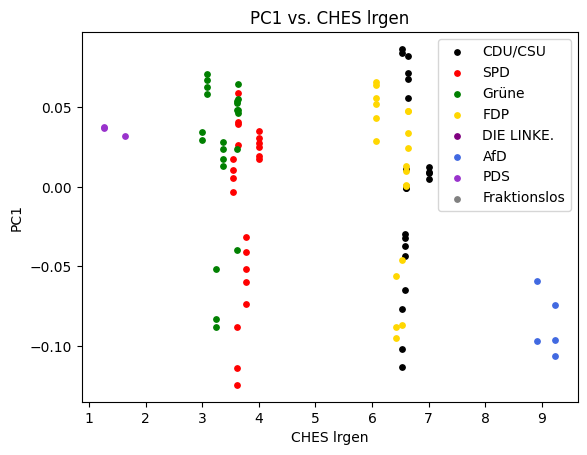

In [ ]:
# plot ches scores vs. PC1
for partei, color in party_colors.items():
    mask = df_agg_ches_scores["party"] == partei
    plt.scatter(df_agg_ches_scores.loc[mask, "lrgen"], pc1_values[mask.values],
                color=color, label=partei, s=15)

plt.xlabel("CHES lrgen")
plt.ylabel("PC1")
plt.legend()
plt.title("PC1 vs. CHES lrgen score")
plt.show()

The plot is consistent with the correlation result: a clear (negative) relationship between the first principal component and lrgen is only really visible at the extremes of the ideological spectrum (for the PDS/LINKE and AfD) while the remaining parties (CDU/CSU, SPD, Grüne, FDP), which occupy the middle of the lrgen scale, show no clear ordering along the first principal component relative to one another.

Since the ideological signal may not be captured by the direction of maximum overall variance, we extend the analysis to the first ten principal components to check whether a later, less dominant component correlates more strongly with lrgen.

In [ ]:
# PCA with 10 components
pca_multi = sk.decomposition.PCA(n_components=10)
pcs = pca_multi.fit_transform(all_embeddings_agg_by_party)

for i in range(10):
    corr, p = pearsonr(pcs[:, i], df_agg_ches_scores["lrgen"])
    print(f"PC{i+1}: r={corr:.3f}, p={p:.3f}, explained_var={pca_multi.explained_variance_ratio_[i]:.3f}")

PC1: r=-0.173, p=0.072, explained_var=0.260
PC2: r=-0.288, p=0.002, explained_var=0.153
PC3: r=0.283, p=0.003, explained_var=0.104
PC4: r=-0.172, p=0.073, explained_var=0.071
PC5: r=0.138, p=0.152, explained_var=0.064
PC6: r=0.400, p=0.000, explained_var=0.053
PC7: r=-0.170, p=0.076, explained_var=0.041
PC8: r=-0.231, p=0.016, explained_var=0.035
PC9: r=0.267, p=0.005, explained_var=0.025
PC10: r=-0.014, p=0.882, explained_var=0.022


Several components show statistically significant correlations with lrgen (e.g. PC2, PC3, PC6, PC8, PC9), with PC6 showing the strongest relationship (r = 0.400, p < 0.001), even though it explains only 5.3% of the total variance, suggesting that ideological information, while present, is distributed across several secondary directions rather than concentrated in the dominant axis of variation.

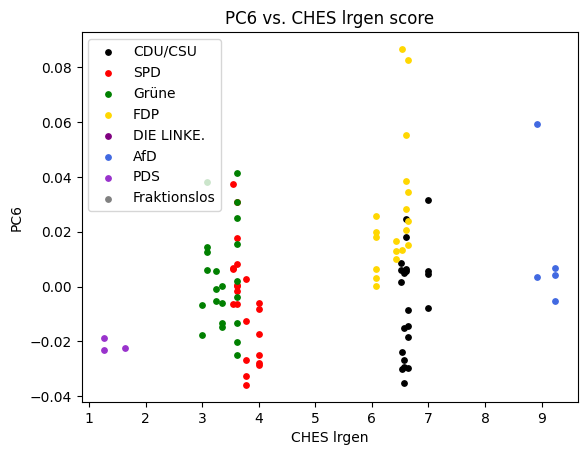

In [43]:
# plot ches scores vs. PC6 (strongest correlation)
for partei, color in party_colors.items():
    mask = df_agg_ches_scores["party"] == partei
    plt.scatter(df_agg_ches_scores.loc[mask, "lrgen"], pcs[mask.values, 5],
                color=color, label=partei, s=15)

plt.xlabel("CHES lrgen")
plt.ylabel("PC6")
plt.legend(loc="upper left")
plt.title("PC6 vs. CHES lrgen score")
plt.show()

### Regression

In [20]:
# train-test-split
gss_reg = sk.model_selection.GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_reg, test_idx_reg = next(gss_reg.split(all_embeddings_agg_by_party, df_agg_ches_scores["lrgen"], groups=df_agg_ches_scores["party"]))

X_train_reg, X_test_reg = all_embeddings_agg_by_party[train_idx_reg], all_embeddings_agg_by_party[test_idx_reg]
y_train_reg, y_test_reg = df_agg_ches_scores["lrgen"].iloc[train_idx_reg], df_agg_ches_scores["lrgen"].iloc[test_idx_reg]

As with the classifier, we use a grouped split (this time grouping by party rather than by politician) to ensure that all years of a given party fall entirely within either the training or the test set. Without this, the regressor could effectively memorize a party's approximate ideological position from other years of the same party rather than learning a relationship that generalizes to unseen parties

In [21]:
# initialize and train regressor
regressor = sk.linear_model.RidgeCV(alphas=np.logspace(-2, 4, 20))
regressor.fit(X_train_reg, y_train_reg)

,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.",array([1.0000...00000000e+04])
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination ` (:math:`R^2`) otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used, else,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",None
,"gcv_mode gcv_mode: {'auto', 'svd', 'eigen'}, default='auto'Flag indicating which strategy to use when performingLeave-One-Out Cross-Validation. Options are:: 'auto' : use 'svd' if n_samples > n_features, otherwise use 'eigen' 'svd' : force use of singular value decomposition of X when X is dense, eigenvalue decomposition of X^T.X when X is sparse. 'eigen' : force computation via eigendecomposition of X.X^TThe 'auto' mode is the default and is intended to pick the cheaperoption of the two depending on the shape of the training data.",None
,"store_cv_results store_cv_results: bool, default=FalseFlag indicating if the cross-validation values corresponding toeach alpha should be stored in the ``cv_results_`` attribute (seebelow). This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionchanged:: 1.5 Parameter name changed from `store_cv_values` to `store_cv_results`.",False
,"alpha_per_target alpha_per_target: bool, default=FalseFlag indicating whether to optimize the alpha value (picked from the`alphas` parameter list) for each target separately (for multi-outputsettings: multiple prediction targets). When set to `True`, afterfitting, the `alpha_` attribute will contain a value for each target.When set to `False`, a single alpha is used for all targets... versionadded:: 0.24",False


Ridge regression extends ordinary linear regression by adding an L2 penalty on the coefficients, which shrinks them toward zero and discourages overly large weights. We use it instead of ordinary least squares, since the number of features (1024) far exceeds the number of observations, making the problem underdetermined; the penalty helps prevent overfitting in this setting.

The alpha parameter controls the strength of this regularization, with larger values shrinking coefficients more aggressively. We select alpha via cross-validation (RidgeCV) over a logarithmically spaced grid of candidate values.

In [51]:
# evaluate regressor 
y_pred_reg = regressor.predict(X_test_reg)
mse = sk.metrics.mean_squared_error(y_test_reg, y_pred_reg)
print('Regressor MSE:', mse)

Regressor MSE: 12.295796920491917


In [46]:
baseline_pred = y_train_reg.mean()
baseline_mse = sk.metrics.mean_squared_error(y_test_reg, [baseline_pred] * len(y_test_reg))
print('Baseline MSE:', baseline_mse)

Baseline MSE: 12.601418628291981


schlecht, kaum besser als basline. Andere Evaluations:

In [53]:
r2 = regressor.score(X_test_reg, y_test_reg)
print('Regressor R2:', r2)

pred_correlation, pred_p_value = pearsonr(y_pred_reg, y_test_reg)
print('Correlation regressor predictions and ches scores:', pred_correlation, 'P_value:', pred_p_value)

Regressor R2: -12.148909747343877
Correlation regressor predictions and ches scores: -0.1527353881390058 P_value: 0.4469189760527534


R2 =-12.15 -> Modellfehler etwa 13-mal so groß ist wie der Fehler der simplen Mittelwert-Baseline (hier Test Mittelwert, oben train Mittelwert!)

correlation ist sogar negativ udn sehr klein, aber nicht significant.


Vlt PCA vor der Regression? (dann ist dim auch so klein, dass man keine ridge regression mehr machen muss)


In [54]:
pca_pcr = sk.decomposition.PCA(n_components=15)
X_train_pcr = pca_pcr.fit_transform(X_train_reg)
X_test_pcr = pca_pcr.transform(X_test_reg)

pcr_model = sk.linear_model.LinearRegression()
pcr_model.fit(X_train_pcr, y_train_reg)

pcr_r2 = pcr_model.score(X_test_pcr, y_test_reg)
print('PCR R2:', pcr_r2)

y_pred_pcr = pcr_model.predict(X_test_pcr)
pcr_mse = sk.metrics.mean_squared_error(y_test_reg, y_pred_pcr)
print('PCR MSE:', pcr_mse)

PCR R2: -12.229584489705955
PCR MSE: 12.371237414628512


immer noch schlecht.